# Retail Insights Analysis

This notebook consolidates the data processing, RFM (Recency, Frequency, Monetary) analysis, customer segmentation (clustering), and product recommendation logic from the Retail Insights Dashboard project.

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# Graphics setup
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Data Loading and Preprocessing

We clean the data by:
- Dropping missing CustomerIDs
- Removing cancellations (InvoiceNo starting with 'C')
- Filtering out non-positive quantities and prices
- Calculating TotalPrice for each line item

In [2]:
def clean_dataframe(df):
    """Validate and clean an uploaded DataFrame."""
    required = {"CustomerID", "InvoiceNo", "InvoiceDate", "StockCode", "Description", "Quantity", "UnitPrice"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {', '.join(sorted(missing))}")

    df = df.dropna(subset=["CustomerID"])
    df["CustomerID"] = df["CustomerID"].astype(int)
    df["StockCode"] = df["StockCode"].astype(str)
    df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
    df = df[df["Quantity"] > 0]
    df = df[df["UnitPrice"] > 0]
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

    if "Country" not in df.columns:
        df["Country"] = ""

    return df.reset_index(drop=True)

# Load the data
DATA_PATH = "data/Online Retail.xlsx"
print(f"Loading data from {DATA_PATH}...")
try:
    df_raw = pd.read_excel(DATA_PATH)
    df = clean_dataframe(df_raw)
    print(f"Successfully loaded and cleaned {len(df):,} rows.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_PATH}. Please ensure the data directory is correct.")

Loading data from data/Online Retail.xlsx...
Successfully loaded and cleaned 397,884 rows.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. RFM Calculation

RFM stands for:
- **Recency**: Days since the last purchase.
- **Frequency**: Number of unique transactions.
- **Monetary**: Total revenue generated by the customer.

In [3]:
def compute_rfm(df):
    """Compute Recency, Frequency, and Monetary for each customer."""
    # Use the day after the last invoice as reference date for recency calculation
    reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

    rfm = df.groupby("CustomerID").agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum"),
    ).reset_index()
    
    return rfm

rfm = compute_rfm(df)
display(rfm.describe())
rfm.head()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


## 4. Customer Segmentation (Clustering)

### 4.1 Feature Scaling
K-Means is distance-based, so we must scale our features (mean=0, std=1).

In [4]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])
rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


### 4.2 Finding Optimal K (Elbow Method)
We plot the Within-Cluster Sum of Squares (WCSS) to find the 'elbow'.

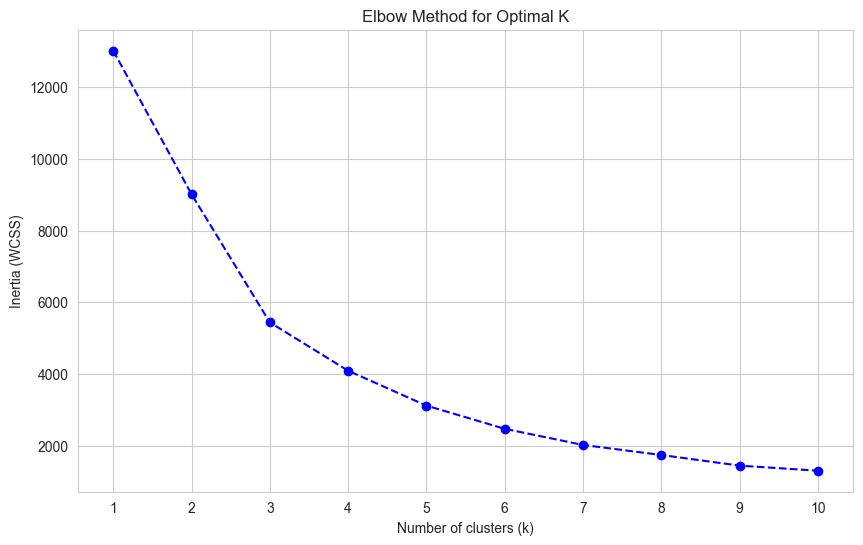

In [5]:
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.show()

### 4.3 Silhouette Analysis
The silhouette score measures how similar an object is to its own cluster compared to other clusters. A higher score indicates better-defined clusters.

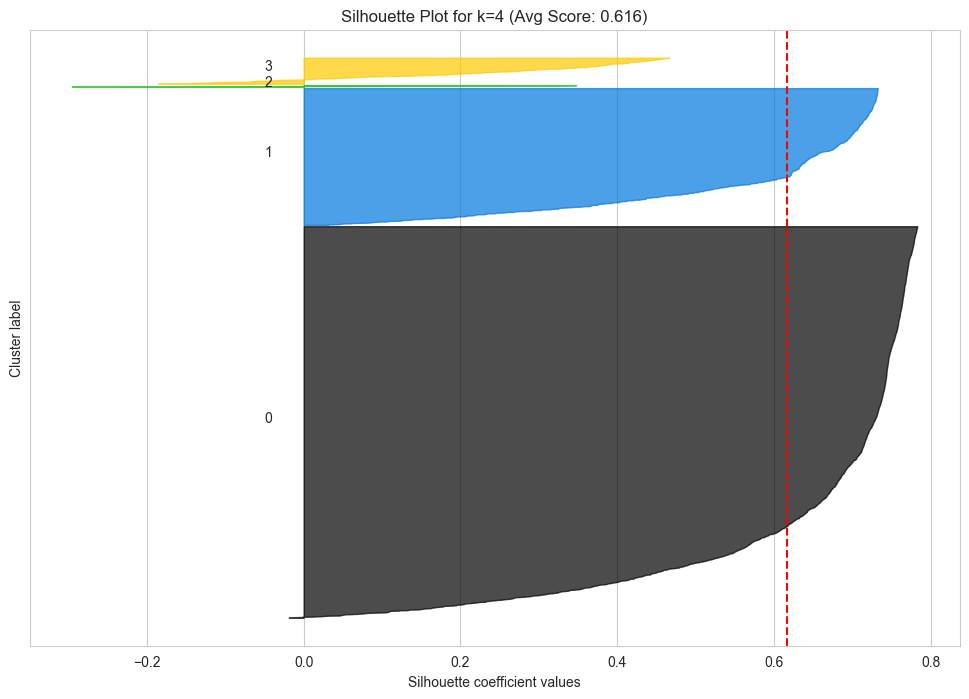

In [6]:
def plot_silhouette(X, n_clusters):
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(12, 8)

    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10 

    ax1.set_title(f"Silhouette Plot for k={n_clusters} (Avg Score: {silhouette_avg:.3f})")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([]) 
    plt.show()

# Check silhouette for k=4 (as used in the app)
plot_silhouette(rfm_scaled, 4)

### 4.4 Final Clustering and Visualization

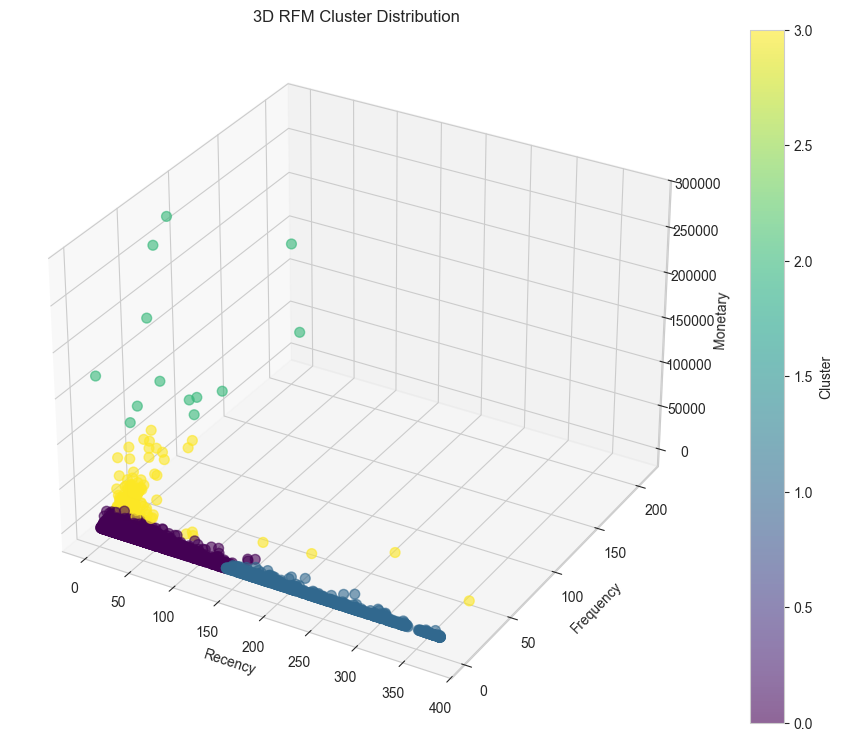

In [7]:
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 3D Plot of Clusters
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
                     c=rfm['Cluster'], cmap='viridis', s=50, alpha=0.6)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('3D RFM Cluster Distribution')
plt.colorbar(scatter, label='Cluster')
plt.show()

## 5. Product Recommendations (Collaborative Filtering)

We use cosine similarity on the user-item matrix to find products that are frequently bought by the same customers.

In [8]:
def build_item_matrix(df):
    """Create a user-item matrix (CustomerID vs StockCode)."""
    return df.groupby(["CustomerID", "StockCode"])["Quantity"].sum().unstack(fill_value=0)

def get_recommendations(matrix, stock_code, top_n=5):
    """Return top N similar products for a given StockCode."""
    if stock_code not in matrix.columns:
        return []

    item_vectors = matrix.T
    target_index = list(item_vectors.index).index(stock_code)
    
    similarities = cosine_similarity(
        item_vectors.iloc[target_index : target_index + 1],
        item_vectors,
    )[0]

    similar_indices = similarities.argsort()[::-1][1 : top_n + 1]
    return [(item_vectors.index[i], similarities[i]) for i in similar_indices]

print("Building item matrix (this may take a moment)...")
matrix = build_item_matrix(df)

# Test with a sample product
sample_code = df['StockCode'].iloc[0]
sample_desc = df[df['StockCode'] == sample_code]['Description'].iloc[0]

print(f"\nTop 5 Recommendations for: {sample_desc} ({sample_code})")
recs = get_recommendations(matrix, sample_code)
for code, sim in recs:
    desc = df[df['StockCode'] == code]['Description'].iloc[0]
    print(f"- {desc} ({code}) | Similarity: {sim:.3f}")

Building item matrix (this may take a moment)...

Top 5 Recommendations for: WHITE HANGING HEART T-LIGHT HOLDER (85123A)
- GIN + TONIC DIET METAL SIGN (21175) | Similarity: 0.750
- RED HANGING HEART T-LIGHT HOLDER (21733) | Similarity: 0.659
- WASHROOM METAL SIGN (82552) | Similarity: 0.644
- LAUNDRY 15C METAL SIGN (82551) | Similarity: 0.642
- GREEN VINTAGE SPOT BEAKER (23288) | Similarity: 0.631
